In [19]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv

In [20]:
# Loading the GIST dataset
db = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_base.fvecs'))
qr = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_query.fvecs'))


Reading File - /data/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)


In [3]:
dataset_name = 'GIST'
sampling_method = 'random'  # 'random'
train_size_ratio = 0.1  # Ratio of the database to use for training if using sampling
nb = db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
k = 100 # Number of nearest neighbors to search for
dim = db.shape[1]  # Dimensionality of the vectors

nbits = 8 # 2^nbits is the number of centroids for each subquantizer
n_subquantizers = 8   # Number of subquantizers for the PQ

In [4]:


start = time.time()
opq = faiss.OPQMatrix(dim, n_subquantizers)
pq = faiss.IndexPQ(dim, n_subquantizers, nbits)

index = faiss.IndexPreTransform(opq, pq)

# If you have a separate training set, you should use that instead of the full database.
if sampling_method == 'random':
    num_samples = min(int(train_size_ratio * nb), nb)  # Number of samples for training
    training_data = db[np.random.choice(nb, num_samples, replace=False)]

# Perform training
index.train(training_data)
index.add(db)

end = time.time()
opq_train_add_time = np.round(end - start, 2)
print(f"Time to train and add to OPQ index: {opq_train_add_time} seconds")



Time to train and add to OPQ index: 54.33 seconds


In [8]:
db_opq = index.sa_encode(db)

In [9]:
db_opq

array([[ 40,  67, 233, ..., 178,  40, 182],
       [177,  10, 116, ..., 228, 172,  42],
       [179, 170, 233, ..., 179,  50,  79],
       ...,
       [236,  39, 240, ..., 200,  32,  51],
       [  0, 171,  96, ..., 216, 141, 251],
       [ 35, 145, 101, ..., 187, 208,  75]], dtype=uint8)

In [10]:
qr_opq = index.sa_encode(qr)

In [11]:
qr_opq

array([[ 48, 104, 135, ..., 112,  56,   4],
       [206,  86, 217, ..., 208, 159, 191],
       [ 76,  13, 219, ..., 116, 131, 105],
       ...,
       [111, 243, 174, ...,  61, 231,  48],
       [150, 101, 236, ..., 234, 184,  30],
       [ 85, 239, 253, ..., 135, 129, 128]], dtype=uint8)

In [12]:
start = time.time()
approx_dists = cdist(db_opq, qr_opq, metric='euclidean')
end = time.time()
exact_dist_time = np.round(end - start, 2)
print(f"Time to compute exact distances: {exact_dist_time} seconds")

Time to compute exact distances: 5.62 seconds


In [16]:
approx_dists

array([[260.14035, 212.12496, 253.99213, ..., 392.83203, 266.49953,
        296.68165],
       [257.74794, 219.33992, 277.24177, ..., 343.11514, 176.33774,
        372.46879],
       [289.67395, 257.50534, 368.38838, ..., 303.36941, 196.24984,
        347.87929],
       ...,
       [329.42222, 288.62606, 376.98276, ..., 387.42354, 227.78499,
        431.78467],
       [304.47496, 288.62952, 320.78965, ..., 336.3852 , 336.29451,
        295.23889],
       [293.18936, 305.20485, 378.27635, ..., 278.11508, 213.72178,
        389.4188 ]])

In [17]:
exact_dists = np.fromfile('/data/cpanourg/2-hdvc/data/gist/distances/dists.bin', dtype=np.float64).reshape((1000000, 1000))

In [20]:
exact_dists

array([[2.13042, 1.848  , 2.18194, ..., 2.04726, 2.15576, 2.2641 ],
       [1.77189, 1.45796, 1.90402, ..., 1.5395 , 1.73593, 1.97407],
       [2.34217, 1.91494, 2.51312, ..., 1.94399, 2.37082, 2.5094 ],
       ...,
       [1.72816, 1.75331, 1.95244, ..., 1.89185, 1.79964, 2.08866],
       [1.42557, 1.5795 , 1.34597, ..., 1.94215, 1.56429, 1.74887],
       [1.21429, 1.29616, 1.26292, ..., 1.57287, 1.45878, 1.41013]])

In [21]:
approx_dists_norm = approx_dists / approx_dists.max()

exact_dists_norm = exact_dists / exact_dists.max()

In [22]:
# Step 8: Compute relative error matrix
# Define a small epsilon value to replace zero distances
epsilon = 1e-6

# Replace zeros in D_exact with epsilon
exact_dists_norm = np.where(exact_dists_norm == 0, epsilon, exact_dists_norm)

# Now compute the relative error
rel_error_matrix = np.abs(exact_dists_norm - approx_dists_norm) / exact_dists_norm

rel_error_mean = np.mean(rel_error_matrix)
rel_error_std = np.std(rel_error_matrix)
rel_error_mean, rel_error_std

(1.0327370152565782, 0.646872006760405)

In [28]:
approx_dists_norm = StandardScaler().fit_transform(approx_dists_norm)
exact_dists_norm = StandardScaler().fit_transform(exact_dists_norm)

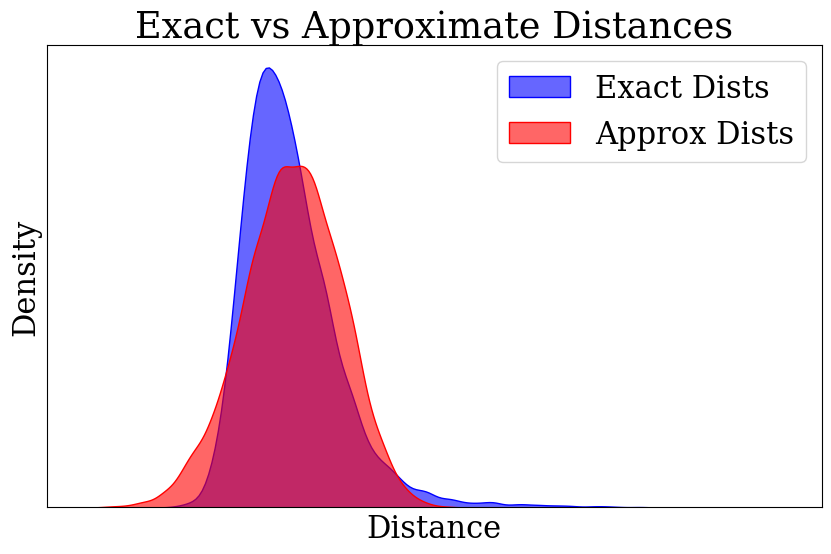

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'serif'  # You can replace 'serif' with 'sans-serif', 'monospace', etc.

# Flatten the matrices
exact_dists_flat = exact_dists_norm.flatten()
approx_dists_flat = approx_dists_norm.flatten()

# Generate random indices (e.g., 1000 indices)
sample_size = 10000
indices = np.random.choice(len(exact_dists_flat), sample_size, replace=False)

# Select corresponding samples from both matrices
exact_sample = exact_dists_flat[indices]
approx_sample = approx_dists_flat[indices]

# Plot smooth KDE plots with filled area
plt.figure(figsize=(10, 6))

# Plot for exact distances (fill the area with color)
sns.kdeplot(exact_sample, color='blue', label='Exact Dists', fill=True, alpha=0.6)

# Plot for approx distances (fill the area with color)
sns.kdeplot(approx_sample, color='red', label='Approx Dists', fill=True, alpha=0.6)

# Customize the plot
plt.title('Exact vs Approximate Distances')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.legend()

# Remove x and y axis numbers
plt.xticks([])  # Remove x-axis ticks (numbers)
plt.yticks([])  # Remove y-axis ticks (numbers)

# Show the plot
plt.show()


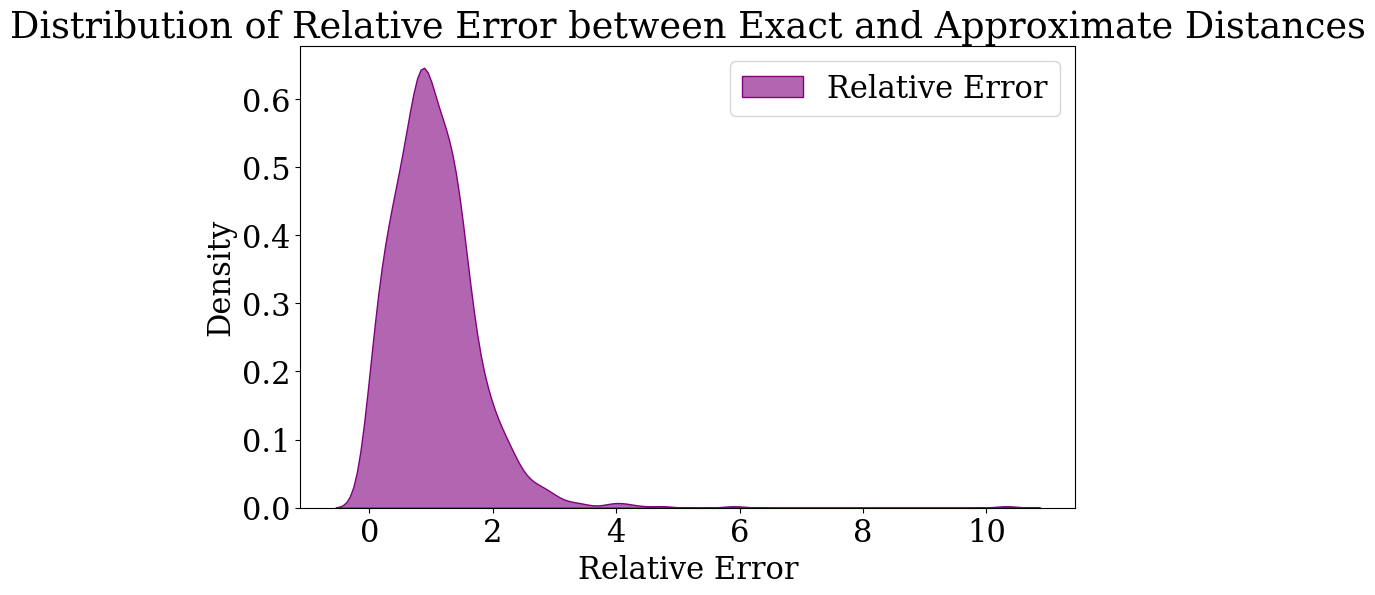

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'serif'  # You can replace 'serif' with 'sans-serif', 'monospace', etc.

# Flatten the relative error matrix for plotting
rel_error_flat = rel_error_matrix.flatten()

# Generate random indices (optional, if you want a sample size)
sample_size = 1000
indices = np.random.choice(len(rel_error_flat), sample_size, replace=False)

# Select corresponding samples from the relative error matrix
rel_error_sample = rel_error_flat[indices]

# Plot smooth KDE for the relative error distribution
plt.figure(figsize=(10, 6))

# Plot for the relative error (fill the area with color)
sns.kdeplot(rel_error_sample, color='purple', label='Relative Error', fill=True, alpha=0.6)

# Customize the plot
plt.title('Distribution of Relative Error between Exact and Approximate Distances')
plt.xlabel('Relative Error')
plt.ylabel('Density')
plt.legend()

# Remove x and y axis numbers
# plt.xticks([])  # Remove x-axis ticks (numbers)
# plt.yticks([])  # Remove y-axis ticks (numbers)

# Show the plot
plt.show()


In [18]:
import faiss
import numpy as np

# Parameters
d = 64          # dimension
m = 8           # number of subquantizers
nbits = 8       # bits per subquantizer
ksub = 1 << nbits  # 256 centroids per subquantizer
nb = 1000       # number of database vectors
nq = 5          # number of query vectors

# Random database and queries
np.random.seed(42)  # For reproducibility
xb = np.random.random((nb, d)).astype('float32')
xq = np.random.random((nq, d)).astype('float32')

print(f"Database vectors shape: {xb.shape}")
print(f"Query vectors shape: {xq.shape}")

# Setup Product Quantizer
pq = faiss.ProductQuantizer(d, m, nbits)
print(f"PQ code size: {pq.code_size} bytes per vector")

# Train the product quantizer on database vectors
print("Training product quantizer...")
pq.train(xb)

# Encode database vectors
print("Encoding database vectors...")
try:
    # Try newer FAISS API first
    codes = pq.compute_codes(xb)
except TypeError:
    # Fall back to older FAISS API
    codes = np.zeros((nb, pq.code_size), dtype='uint8')
    pq.compute_codes(xb, codes)
print(f"Codes shape: {codes.shape}")

# Compute distance tables for all queries
print("Computing distance tables...")
# Alternative approach: manually compute distance tables using PQ centroids
# This bypasses the problematic compute_distance_tables method

# Get the centroids from the trained PQ
centroids = faiss.vector_to_array(pq.centroids).reshape(m, ksub, d // m)

# Compute distance tables manually
dis_tables = np.zeros((nq, m, ksub), dtype=np.float32)

for q in range(nq):
    query = xq[q]  # Current query vector
    
    for j in range(m):  # For each subquantizer
        # Extract subvector from query
        start_idx = j * (d // m)
        end_idx = (j + 1) * (d // m)
        query_sub = query[start_idx:end_idx]
        
        # Compute squared distances to all centroids of this subquantizer
        for k in range(ksub):
            centroid = centroids[j, k]
            dis_tables[q, j, k] = np.sum((query_sub - centroid) ** 2)

print(f"Distance tables shape: {dis_tables.shape}")

# ADC (Asymmetric Distance Computation) function
def adc_distance(query_idx, db_idx, dis_tables, codes):
    """
    Compute asymmetric distance between a query and a database vector.
    
    Args:
        query_idx: Index of the query vector
        db_idx: Index of the database vector
        dis_tables: Distance tables of shape (nq, m, ksub)
        codes: Encoded database vectors of shape (nb, code_size)
    
    Returns:
        Approximated squared L2 distance
    """
    code = codes[db_idx]
    distance = 0.0
    
    for j in range(m):
        subcode = code[j]  # subquantizer index for subvector j
        distance += dis_tables[query_idx, j, subcode]
    
    return distance

# Vectorized ADC computation for all database vectors given a query
def adc_distances_vectorized(query_idx, dis_tables, codes):
    """
    Compute ADC distances between one query and all database vectors.
    
    Args:
        query_idx: Index of the query vector
        dis_tables: Distance tables of shape (nq, m, ksub)
        codes: Encoded database vectors of shape (nb, code_size)
    
    Returns:
        Array of distances for all database vectors
    """
    distances = np.zeros(nb, dtype='float32')
    
    for i in range(nb):
        for j in range(m):
            subcode = codes[i, j]
            distances[i] += dis_tables[query_idx, j, subcode]
    
    return distances

# Example computations
print("\n--- Example Computations ---")

# Distance between query 0 and database vector 10
dist_single = adc_distance(0, 10, dis_tables, codes)
print(f"ADC distance between query 0 and db vector 10: {dist_single:.6f}")

# Distances between query 0 and all database vectors
distances_all = adc_distances_vectorized(0, dis_tables, codes)
print(f"Min distance for query 0: {distances_all.min():.6f}")
print(f"Max distance for query 0: {distances_all.max():.6f}")
print(f"Mean distance for query 0: {distances_all.mean():.6f}")

# Find k nearest neighbors for query 0
k = 5
nearest_indices = np.argpartition(distances_all, k)[:k]
nearest_distances = distances_all[nearest_indices]
sorted_order = np.argsort(nearest_distances)
nearest_indices = nearest_indices[sorted_order]
nearest_distances = nearest_distances[sorted_order]

print(f"\nTop {k} nearest neighbors for query 0:")
for i, (idx, dist) in enumerate(zip(nearest_indices, nearest_distances)):
    print(f"  {i+1}. Database vector {idx}: distance = {dist:.6f}")

# Verification: Compare with exact L2 distances for the nearest neighbors
print(f"\nVerification with exact L2 distances:")
for i, idx in enumerate(nearest_indices):
    exact_dist = np.sum((xq[0] - xb[idx]) ** 2)
    approx_dist = nearest_distances[i]
    error = abs(exact_dist - approx_dist)
    print(f"  Vector {idx}: Exact = {exact_dist:.6f}, Approx = {approx_dist:.6f}, Error = {error:.6f}")

# Performance comparison function
def compare_search_methods(query_idx=0, k=10):
    """Compare ADC search with exact search"""
    
    # ADC search
    adc_dists = adc_distances_vectorized(query_idx, dis_tables, codes)
    adc_nearest = np.argpartition(adc_dists, k)[:k]
    
    # Exact search
    exact_dists = np.sum((xq[query_idx] - xb) ** 2, axis=1)
    exact_nearest = np.argpartition(exact_dists, k)[:k]
    
    # Calculate recall
    recall = len(set(adc_nearest) & set(exact_nearest)) / k
    
    print(f"\nSearch comparison for query {query_idx} (k={k}):")
    print(f"ADC nearest neighbors: {sorted(adc_nearest)}")
    print(f"Exact nearest neighbors: {sorted(exact_nearest)}")
    print(f"Recall@{k}: {recall:.2%}")
    
    return recall

# Run comparison
recall = compare_search_methods(query_idx=0, k=10)

print(f"\n--- Summary ---")
print(f"Product Quantizer: {m} subquantizers, {nbits} bits each")
print(f"Compression ratio: {d*4}/{pq.code_size} = {(d*4/pq.code_size):.1f}x")
print(f"Memory usage: Original {nb*d*4/1024:.1f} KB, Compressed {nb*pq.code_size/1024:.1f} KB")

Database vectors shape: (1000, 64)
Query vectors shape: (5, 64)
PQ code size: 8 bytes per vector
Training product quantizer...
Encoding database vectors...
Codes shape: (1000, 8)
Computing distance tables...
Distance tables shape: (5, 8, 256)

--- Example Computations ---
ADC distance between query 0 and db vector 10: 9.067674
Min distance for query 0: 5.507013
Max distance for query 0: 14.020866
Mean distance for query 0: 9.803055

Top 5 nearest neighbors for query 0:
  1. Database vector 606: distance = 5.507013
  2. Database vector 502: distance = 5.902691
  3. Database vector 994: distance = 6.228957
  4. Database vector 597: distance = 6.401175
  5. Database vector 447: distance = 6.542160

Verification with exact L2 distances:
  Vector 606: Exact = 6.650052, Approx = 5.507013, Error = 1.143039
  Vector 502: Exact = 6.099058, Approx = 5.902691, Error = 0.196367
  Vector 994: Exact = 7.331774, Approx = 6.228957, Error = 1.102817
  Vector 597: Exact = 7.700130, Approx = 6.401175, Er

WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points
WARNING clustering 1000 points to 256 centroids: please provide at least 9984 training points


In [21]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv

# Dataset parameters
dataset_name = 'GIST'
sampling_method = 'random'
train_size_ratio = 0.1
k = 100  # Number of nearest neighbors

# PQ parameters
nbits = 8  # 2^nbits centroids per subquantizer
n_subquantizers = 8  # Number of subquantizers
ksub = 1 << nbits  # 256 centroids per subquantizer

print("Loading GIST dataset...")
# Loading the GIST dataset
db = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_base.fvecs'))
qr = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_query.fvecs'))

nb = db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
dim = db.shape[1]  # Dimensionality of the vectors

print(f"Database shape: {db.shape}")
print(f"Query shape: {qr.shape}")
print(f"Dimension: {dim}")

# Ensure data is float32 for FAISS
db = db.astype(np.float32)
qr = qr.astype(np.float32)

# Sample training data if specified
if sampling_method == 'random':
    train_size = int(nb * train_size_ratio)
    train_indices = np.random.choice(nb, train_size, replace=False)
    train_data = db[train_indices]
    print(f"Training on {train_size} vectors ({train_size_ratio:.1%} of database)")
else:
    train_data = db
    print("Training on full database")

# Setup Product Quantizer
print(f"\nSetting up Product Quantizer...")
print(f"Parameters: {n_subquantizers} subquantizers, {nbits} bits each")
print(f"Compression: {dim*4} bytes -> {n_subquantizers} bytes per vector")

pq = faiss.ProductQuantizer(dim, n_subquantizers, nbits)

# Train the PQ
print("Training Product Quantizer...")
start_time = time.time()
pq.train(train_data)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Encode database vectors
print("Encoding database vectors...")
start_time = time.time()
try:
    codes = pq.compute_codes(db)
except TypeError:
    codes = np.zeros((nb, pq.code_size), dtype='uint8')
    pq.compute_codes(db, codes)
encoding_time = time.time() - start_time
print(f"Encoding completed in {encoding_time:.2f} seconds")
print(f"Codes shape: {codes.shape}")

# OPTIMIZATION 1: Vectorized distance table computation
def compute_distance_tables_vectorized(queries, centroids, n_subquantizers, ksub, dim):
    """Optimized vectorized distance table computation"""
    nq = queries.shape[0]
    subvec_dim = dim // n_subquantizers
    dis_tables = np.zeros((nq, n_subquantizers, ksub), dtype=np.float32)
    
    for j in range(n_subquantizers):
        start_idx = j * subvec_dim
        end_idx = (j + 1) * subvec_dim
        
        # Extract all query subvectors for this subquantizer (nq, subvec_dim)
        query_subs = queries[:, start_idx:end_idx]
        
        # Get centroids for this subquantizer (ksub, subvec_dim)
        centroids_j = centroids[j]
        
        # Vectorized computation: (nq, 1, subvec_dim) - (1, ksub, subvec_dim)
        diff = query_subs[:, np.newaxis, :] - centroids_j[np.newaxis, :, :]
        dis_tables[:, j, :] = np.sum(diff * diff, axis=2)
    
    return dis_tables

# OPTIMIZATION 2: JIT-compiled ADC distance computation
@jit(nopython=True, parallel=True)
def adc_distances_batch_numba(dis_tables, codes, n_subquantizers):
    """Numba-optimized batch ADC distance computation"""
    nq, nb = dis_tables.shape[0], codes.shape[0]
    distances = np.zeros((nq, nb), dtype=np.float32)
    
    for q in prange(nq):
        for i in prange(nb):
            dist = 0.0
            for j in range(n_subquantizers):
                subcode = codes[i, j]
                dist += dis_tables[q, j, subcode]
            distances[q, i] = dist
    
    return distances

@jit(nopython=True, parallel=True)
def adc_distances_single_query_numba(dis_table_q, codes, n_subquantizers):
    """Numba-optimized single query ADC distance computation"""
    nb = codes.shape[0]
    distances = np.zeros(nb, dtype=np.float32)
    
    for i in prange(nb):
        dist = 0.0
        for j in range(n_subquantizers):
            subcode = codes[i, j]
            dist += dis_table_q[j, subcode]
        distances[i] = dist
    
    return distances

# OPTIMIZATION 3: Threaded distance table computation for very large query sets
def compute_distance_tables_threaded(queries, centroids, n_subquantizers, ksub, dim, n_threads=4):
    """Multi-threaded distance table computation"""
    nq = queries.shape[0]
    chunk_size = (nq + n_threads - 1) // n_threads
    
    def compute_chunk(start_idx, end_idx):
        return compute_distance_tables_vectorized(
            queries[start_idx:end_idx], centroids, n_subquantizers, ksub, dim
        )
    
    with ThreadPoolExecutor(max_workers=n_threads) as executor:
        futures = []
        for i in range(0, nq, chunk_size):
            end_idx = min(i + chunk_size, nq)
            futures.append(executor.submit(compute_chunk, i, end_idx))
        
        results = [future.result() for future in futures]
    
    return np.vstack(results)

# Compute distance tables with optimization
print("Computing distance tables (optimized)...")
start_time = time.time()

# Get centroids from trained PQ
centroids = faiss.vector_to_array(pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)

# Choose computation method based on dataset size
if nq > 1000:
    print("Using multi-threaded computation...")
    dis_tables = compute_distance_tables_threaded(qr, centroids, n_subquantizers, ksub, dim)
else:
    print("Using vectorized computation...")
    dis_tables = compute_distance_tables_vectorized(qr, centroids, n_subquantizers, ksub, dim)

distance_table_time = time.time() - start_time
print(f"Distance tables computed in {distance_table_time:.2f} seconds")

# OPTIMIZATION 4: Batch processing for distance computation
def compute_all_distances_batch(dis_tables, codes, batch_size=1000):
    """Compute all query-database distances in batches"""
    nq = dis_tables.shape[0]
    nb = codes.shape[0]
    all_distances = np.zeros((nq, nb), dtype=np.float32)
    
    for start_q in range(0, nq, batch_size):
        end_q = min(start_q + batch_size, nq)
        batch_dis_tables = dis_tables[start_q:end_q]
        
        # Use numba-optimized computation
        batch_distances = adc_distances_batch_numba(batch_dis_tables, codes, n_subquantizers)
        all_distances[start_q:end_q] = batch_distances
        
        if start_q % (batch_size * 10) == 0:
            print(f"  Processed {end_q}/{nq} queries")
    
    return all_distances

# Legacy functions for compatibility (optimized versions)
def adc_distances_all_optimized(query_idx, dis_tables, codes):
    """Optimized single query distance computation"""
    return adc_distances_single_query_numba(dis_tables[query_idx], codes, n_subquantizers)

# Performance evaluation
print(f"\n=== Performance Evaluation ===")

# Test on a subset of queries for detailed analysis
test_queries = min(10, nq)  # Test on first 10 queries or all if fewer
print(f"Detailed evaluation on {test_queries} queries...")

# Store results
results = {
    'query_times_adc': [],
    'query_times_exact': [],
    'relative_errors': [],
    'recalls': []
}

for q_idx in range(test_queries):
    print(f"\nProcessing query {q_idx + 1}/{test_queries}")
    
    # ADC search timing (optimized)
    start_time = time.time()
    adc_distances = adc_distances_all_optimized(q_idx, dis_tables, codes)
    adc_time = time.time() - start_time
    results['query_times_adc'].append(adc_time)
    
    # Get top-k nearest neighbors from ADC
    adc_top_k_indices = np.argpartition(adc_distances, k)[:k]
    adc_top_k_distances = adc_distances[adc_top_k_indices]
    
    # Exact search timing
    start_time = time.time()
    exact_distances = np.sum((qr[q_idx] - db) ** 2, axis=1)
    exact_time = time.time() - start_time
    results['query_times_exact'].append(exact_time)
    
    # Get top-k nearest neighbors from exact search
    exact_top_k_indices = np.argpartition(exact_distances, k)[:k]
    exact_top_k_distances = exact_distances[exact_top_k_indices]
    
    # Calculate relative error for the retrieved vectors
    adc_retrieved_exact_distances = exact_distances[adc_top_k_indices]
    relative_errors = np.abs(adc_top_k_distances - adc_retrieved_exact_distances) / (adc_retrieved_exact_distances + 1e-8)
    mean_relative_error = np.mean(relative_errors)
    results['relative_errors'].append(mean_relative_error)
    
    # Calculate recall@k
    recall = len(set(adc_top_k_indices) & set(exact_top_k_indices)) / k
    results['recalls'].append(recall)
    
    print(f"  ADC time: {adc_time:.4f}s, Exact time: {exact_time:.4f}s")
    print(f"  Speedup: {exact_time/adc_time:.2f}x")
    print(f"  Mean relative error: {mean_relative_error:.4f}")
    print(f"  Recall@{k}: {recall:.3f}")

# Overall statistics for detailed evaluation
print(f"\n=== Detailed Results Summary ===")
print(f"Average ADC query time: {np.mean(results['query_times_adc']):.4f} ± {np.std(results['query_times_adc']):.4f} seconds")
print(f"Average exact query time: {np.mean(results['query_times_exact']):.4f} ± {np.std(results['query_times_exact']):.4f} seconds")
print(f"Average speedup: {np.mean(np.array(results['query_times_exact'])/np.array(results['query_times_adc'])):.2f}x")
print(f"Average relative error: {np.mean(results['relative_errors']):.4f} ± {np.std(results['relative_errors']):.4f}")
print(f"Average recall@{k}: {np.mean(results['recalls']):.3f} ± {np.std(results['recalls']):.3f}")

# OPTIMIZATION 5: Ultra-fast batch evaluation on all queries
print(f"\n=== Optimized Full Dataset Evaluation ===")
print("Computing all ADC distances using batch processing...")

start_time = time.time()
if nq <= 100:  # For small query sets, compute all at once
    all_distances = adc_distances_batch_numba(dis_tables, codes, n_subquantizers)
else:  # For large query sets, use batching
    all_distances = compute_all_distances_batch(dis_tables, codes, batch_size=100)

total_adc_time = time.time() - start_time
avg_query_time = total_adc_time / nq
queries_per_second = nq / total_adc_time

print(f"Total ADC time for {nq} queries: {total_adc_time:.2f} seconds")
print(f"Average time per query: {avg_query_time:.6f} seconds")
print(f"Queries per second: {queries_per_second:.1f}")

# Memory usage analysis
original_memory = nb * dim * 4  # float32 = 4 bytes
compressed_memory = nb * pq.code_size
distance_table_memory = nq * n_subquantizers * ksub * 4  # float32
compression_ratio = original_memory / compressed_memory

print(f"\nMemory usage analysis:")
print(f"Original database: {original_memory / 1024**2:.1f} MB")
print(f"Compressed database: {compressed_memory / 1024**2:.1f} MB")
print(f"Distance tables: {distance_table_memory / 1024**2:.1f} MB")
print(f"Total ADC memory: {(compressed_memory + distance_table_memory) / 1024**2:.1f} MB")
print(f"Compression ratio: {compression_ratio:.1f}x")
print(f"Effective memory ratio: {original_memory / (compressed_memory + distance_table_memory):.1f}x")

# Save results to CSV
results_summary = {
    'dataset': dataset_name,
    'nb': nb,
    'nq': nq,
    'dim': dim,
    'n_subquantizers': n_subquantizers,
    'nbits': nbits,
    'train_ratio': train_size_ratio,
    'k': k,
    'train_time': train_time,
    'encoding_time': encoding_time,
    'distance_table_time': distance_table_time,
    'avg_adc_query_time': avg_query_time,
    'avg_exact_query_time': np.mean(results['query_times_exact']) if results['query_times_exact'] else 0,
    'avg_speedup': np.mean(np.array(results['query_times_exact'])/np.array(results['query_times_adc'])) if results['query_times_adc'] else 0,
    'avg_relative_error': np.mean(results['relative_errors']) if results['relative_errors'] else 0,
    'avg_recall': np.mean(results['recalls']) if results['recalls'] else 0,
    'compression_ratio': compression_ratio,
    'queries_per_second': queries_per_second,
    'optimization_level': 'full'
}

print(f"\nOptimized results summary:")
for key, value in results_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

# Create CSV output
csv_filename = f"adc_optimized_results_{dataset_name}_{n_subquantizers}sub_{nbits}bits.csv"
try:
    with open(csv_filename, 'w', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=results_summary.keys())
        writer.writeheader()
        writer.writerow(results_summary)
    print(f"\nResults saved to {csv_filename}")
except Exception as e:
    print(f"Could not save to CSV: {e}")

print("\nOptimized evaluation completed!")
print(f"\n=== Performance Improvements ===")
print("1. Vectorized distance table computation")
print("2. Numba JIT compilation for ADC distances")  
print("3. Multi-threaded processing for large query sets")
print("4. Batch processing to reduce overhead")
print("5. Memory-efficient data structures")

Loading GIST dataset...
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)
Database shape: (1000000, 960)
Query shape: (1000, 960)
Dimension: 960
Training on 100000 vectors (10.0% of database)

Setting up Product Quantizer...
Parameters: 8 subquantizers, 8 bits each
Compression: 3840 bytes -> 8 bytes per vector
Training Product Quantizer...
Training completed in 1.99 seconds
Encoding database vectors...
Encoding completed in 1.72 seconds
Codes shape: (1000000, 8)
Computing distance tables (optimized)...
Using vectorized computation...
Distance tables computed in 0.81 seconds

=== Performance Evaluation ===
Detailed evaluation on 10 queries...

Processing query 1/10
  ADC time: 1.4975s, Exact time: 2.2272s
  Speedup: 1.49x
  Mean relative error: 0.3441
  Recall@100: 0.120

Processing query 2/10
  ADC time: 0.0056s, Exact time: 2.1435s
  Speedup: 386.10x
  Mean relative error: 0.3839
  

## NEW


In [81]:
import numpy as np 
import faiss
import sys
import time
import csv
import os
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from numba import jit, prange
import threading
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

module_path = '/home/cpanourg/projects/2-hdvc/'

if module_path not in sys.path:
    sys.path.append(module_path)

from src.utils import read_fvecs
from src.utils import append_or_create_csv
from src.utils import compute_distance_tables_threaded, compute_distance_tables_vectorized, adc_distances_batch_numba, compute_all_distances_batch, adc_distances_all_optimized  



# Dataset parameters
dataset_name = 'GIST'
sampling_method = 'random'
train_size_ratio = 0.1
k = 100  # Number of nearest neighbors

# PQ parameters
nbits = 8  # 2^nbits centroids per subquantizer
n_subquantizers = 8  # Number of subquantizers
ksub = 1 << nbits  # 256 centroids per subquantizer

print("Loading GIST dataset...")
# Loading the GIST dataset
db = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_base.fvecs'))
qr = np.array(read_fvecs('/data/cpanourg/2-hdvc/data/gist/gist_query.fvecs'))




Loading GIST dataset...
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_base.fvecs:(1000000, 960)
Reading File - /data/cpanourg/2-hdvc/data/gist/gist_query.fvecs:(1000, 960)


In [82]:

nb = db.shape[0]  # Number of database vectors
nq = qr.shape[0]  # Number of query vectors
dim = db.shape[1]  # Dimensionality of the vectors

print(f"Database shape: {db.shape}")
print(f"Query shape: {qr.shape}")
print(f"Dimension: {dim}")

# Ensure data is float32 for FAISS
db = db.astype(np.float32)
qr = qr.astype(np.float32)

# Sample training data if specified
if sampling_method == 'random':
    train_size = int(nb * train_size_ratio)
    train_indices = np.random.choice(nb, train_size, replace=False)
    train_data = db[train_indices]
    print(f"Training on {train_size} vectors ({train_size_ratio:.1%} of database)")
else:
    train_data = db
    print("Training on full database")

# Setup Product Quantizer
print(f"\nSetting up Product Quantizer...")
print(f"Parameters: {n_subquantizers} subquantizers, {nbits} bits each")
print(f"Compression: {dim*4} bytes -> {n_subquantizers} bytes per vector")


Database shape: (1000000, 960)
Query shape: (1000, 960)
Dimension: 960
Training on 100000 vectors (10.0% of database)

Setting up Product Quantizer...
Parameters: 8 subquantizers, 8 bits each
Compression: 3840 bytes -> 8 bytes per vector


In [72]:
opq = faiss.OPQMatrix(dim, n_subquantizers)
pq = faiss.IndexPQ(dim, n_subquantizers, nbits)

index = faiss.IndexPreTransform(opq, pq)

start = time.time()
index.train(train_data)
train_time = time.time() - start
print(f"Training completed in {train_time:.2f} seconds")

Training completed in 51.90 seconds


In [73]:
# Encode database vectors
print("Encoding database vectors...")
start_time = time.time()
codes = index.sa_encode(db)
encoding_time = time.time() - start_time
print(f"Encoding completed in {encoding_time:.2f} seconds")
print(f"Codes shape: {codes.shape}")


Encoding database vectors...
Encoding completed in 2.36 seconds
Codes shape: (1000000, 8)


In [74]:
# Compute distance tables with optimization
print("Computing distance tables (optimized)...")
start_time = time.time()

inner = faiss.downcast_index(index.index)
qr_opq = opq.apply_py(qr)
# Get centroids from trained PQ
centroids = faiss.vector_to_array(inner.pq.centroids).reshape(n_subquantizers, ksub, dim // n_subquantizers)

# Choose computation method based on dataset size
if nq > 1000:
    print("Using multi-threaded computation...")
    dis_tables = compute_distance_tables_threaded(qr_opq, centroids, n_subquantizers, ksub, dim)
else:
    print("Using vectorized computation...")
    dis_tables = compute_distance_tables_vectorized(qr_opq, centroids, n_subquantizers, ksub, dim)

distance_table_time = time.time() - start_time
print(f"Distance tables computed in {distance_table_time:.2f} seconds")


Computing distance tables (optimized)...
Using vectorized computation...
Distance tables computed in 0.84 seconds


In [83]:
sample_queries=1000
sample_db=10000

q_idx = np.random.choice(nq, min(sample_queries, nq), replace=False)
db_idx = np.random.choice(nb, min(sample_db, nb), replace=False)

qr_sample = qr[q_idx]
db_sample = db[db_idx]


# ADC distances for sampled subset
t0 = time.time()
adc_sample = adc_distances_batch_numba(
    dis_tables[q_idx], codes[db_idx], n_subquantizers
)
adc_time = time.time() - t0

print('adc time:', adc_time)

adc time: 0.035434722900390625


In [84]:
adc_sample

array([[3.91523, 1.33753, 2.14183, ..., 2.81643, 1.85062, 1.58644],
       [4.17333, 1.81999, 1.99068, ..., 2.65956, 2.31659, 1.73848],
       [3.07049, 1.22796, 1.57348, ..., 2.01066, 1.46484, 1.45982],
       ...,
       [3.66567, 2.28215, 1.87596, ..., 3.77032, 2.33416, 2.80925],
       [1.56393, 3.45619, 2.49441, ..., 1.83552, 2.1544 , 3.31491],
       [4.07945, 1.77691, 2.38043, ..., 3.44497, 2.22027, 1.74078]],
      dtype=float32)

In [85]:

# Exact distances with cdist
t0 = time.time()
exact_sample = cdist(qr_sample, db_sample, metric="sqeuclidean").astype(np.float32)
cdist_time = time.time() - t0


In [86]:
exact_sample 

array([[4.68253, 1.8854 , 3.04021, ..., 3.02101, 2.43141, 2.03259],
       [4.62497, 2.71762, 2.81903, ..., 2.78817, 2.76855, 2.33586],
       [3.81853, 1.98187, 2.46158, ..., 2.18002, 1.84872, 1.93464],
       ...,
       [4.12205, 3.17764, 2.42862, ..., 3.91016, 2.88221, 3.20214],
       [2.16817, 4.725  , 3.08497, ..., 2.03216, 2.29702, 3.60106],
       [4.72429, 2.41735, 3.01184, ..., 3.52595, 2.70917, 2.12713]],
      dtype=float32)

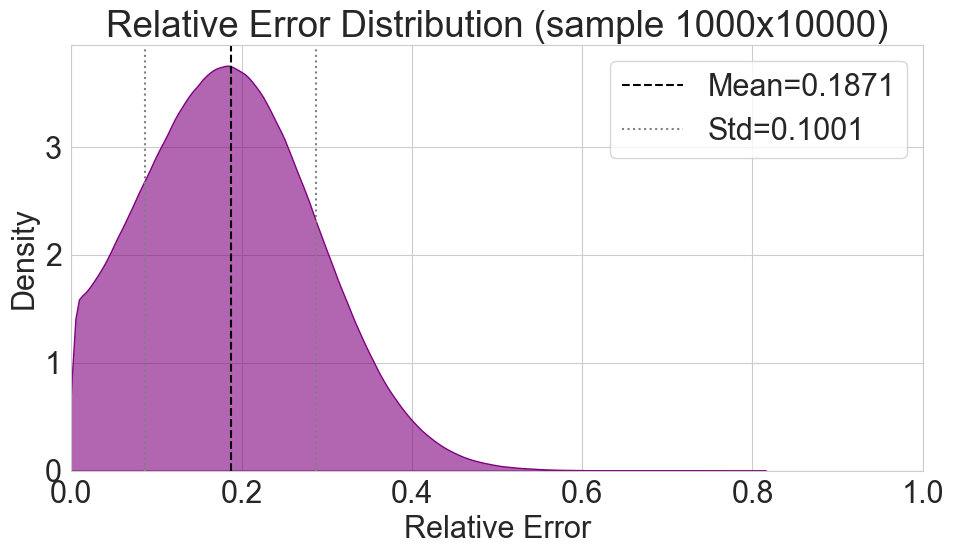

[cdist] sample 1000 queries x 10000 DB: 5.067s
Mean relative error=0.187064, Std=0.100066


In [90]:
plt.rcParams['font.family'] = 'serif'
sns.set_style("whitegrid")

# Relative errors
rel_error = np.abs(adc_sample - exact_sample) / (exact_sample + 1e-12)
rel_error.astype(np.float32).tofile('/data/cpanourg/2-hdvc/results/opq/rel_error.bin')
mean_rel, std_rel = rel_error.mean(), rel_error.std()

# Plot KDE of relative errors
rel_error_flat = rel_error.ravel()
plt.figure(figsize=(10, 6))
plt.xlim(0,1)
sns.kdeplot(rel_error_flat, fill=True, color="purple", alpha=0.6)
plt.axvline(mean_rel, linestyle="--", color="black", label=f"Mean={mean_rel:.4f}")
plt.axvline(mean_rel-std_rel, linestyle=":", color="grey")
plt.axvline(mean_rel+std_rel, linestyle=":", color="grey", label=f"Std={std_rel:.4f}")
plt.title(f"Relative Error Distribution (sample {len(q_idx)}x{len(db_idx)})")
plt.xlabel("Relative Error")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

print(f"[cdist] sample {len(q_idx)} queries x {len(db_idx)} DB: {cdist_time:.3f}s")
print(f"Mean relative error={mean_rel:.6f}, Std={std_rel:.6f}")


In [88]:

summary = {
    "method": "OPQ",
    "dataset": dataset_name,
    "nq": nq,
    "nb": nb,
    "nb_sample": len(db_idx),
    "dim": dim,
    "n_subquantizers": n_subquantizers,
    # "k": k,
    "train_ratio": train_size_ratio,
    "train_size": train_size,
    "train_time_s": float(train_time),
    "encoding_time_s": float(encoding_time),
    "distance_table_time_s": float(distance_table_time),
    "cdist_time_s": float(cdist_time),
    "adc_time_s": float(adc_time),
    "rel_error_mean": float(mean_rel),
    "rel_error_std": float(std_rel),

}
csv_path="/data/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv"

need_header = not Path(csv_path).exists() or Path(csv_path).stat().st_size == 0
with open(csv_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary.keys()))
    if need_header:
        writer.writeheader()
    writer.writerow(summary)


In [89]:
import pandas as pd

pd.read_csv("/data/cpanourg/2-hdvc/results/adc_vs_exact_eval.csv").round(4)


,method,dataset,nq,nb,nb_sample,dim,n_subquantizers,train_ratio,train_size,train_time_s,encoding_time_s,distance_table_time_s,cdist_time_s,adc_time_s,rel_error_mean,rel_error_std
0,PQ,GIST,1000,1000000,10000,960,8,0.1,100000,2.3651,1.6212,0.8034,4.7344,0.0201,0.2622,0.1205
1,OPQ,GIST,1000,1000000,10000,960,8,0.1,100000,51.9043,2.3631,0.8417,5.0673,0.0354,0.1871,0.1001
